In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Load MRI scan (.nii or .nii.gz)
img = nib.load(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w.nii\sub-01_T1w.nii")   # change path if needed
data = img.get_fdata()

print("MRI Shape:", data.shape)

# Function to display slice
def view_slice(slice_index):
    plt.figure(figsize=(6,6))
    plt.imshow(data[:, :, slice_index], cmap="gray")
    plt.title(f"Slice {slice_index}")
    plt.axis("off")
    plt.show()

# Create interactive slider
interact(
    view_slice,
    slice_index=IntSlider(
        min=0,
        max=data.shape[2]-1,
        step=1,
        value=data.shape[2]//2
    )
)

MRI Shape: (176, 256, 256)


interactive(children=(IntSlider(value=128, description='slice_index', max=255), Output()), _dom_classes=('widg…

<function __main__.view_slice(slice_index)>

In [11]:
import subprocess

subprocess.run([
    "wsl",
    "fslreorient2std",
    "/mnt/c/Users/sucha/OneDrive/Documents/schizobrain-Scan/MRI_data/open_neuro/open_neuro_4_99/sub-01_T1w/sub-01_T1w.nii",
    "/mnt/c/Users/sucha/OneDrive/Documents/schizobrain-Scan/MRI_data/open_neuro/open_neuro_4_99/sub-01_T1w/test.nii"
])

CompletedProcess(args=['wsl', 'fslreorient2std', '/mnt/c/Users/sucha/OneDrive/Documents/schizobrain-Scan/MRI_data/open_neuro/open_neuro_4_99/sub-01_T1w/sub-01_T1w.nii', '/mnt/c/Users/sucha/OneDrive/Documents/schizobrain-Scan/MRI_data/open_neuro/open_neuro_4_99/sub-01_T1w/test.nii'], returncode=127)

In [ ]:
# import nibabel as nib
# import numpy as np
# import matplotlib.pyplot as plt
# from ipywidgets import interact, IntSlider

# # Load MRI scan (.nii or .nii.gz)
# img = nib.load(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\sub-01_T1w.nii")   # change path if needed
# data = img.get_fdata()

# print("MRI Shape:", data.shape)

# # Function to display slice
# def view_slice(slice_index):
#     plt.figure(figsize=(6,6))
#     plt.imshow(data[:, :, slice_index], cmap="gray")
#     plt.title(f"Slice {slice_index}")
#     plt.axis("off")
#     plt.show()

# # Create interactive slider
# interact(
#     view_slice,
#     slice_index=IntSlider(
#         min=0,
#         max=data.shape[2]-1,
#         step=1,
#         value=data.shape[2]//2
#     )
# )

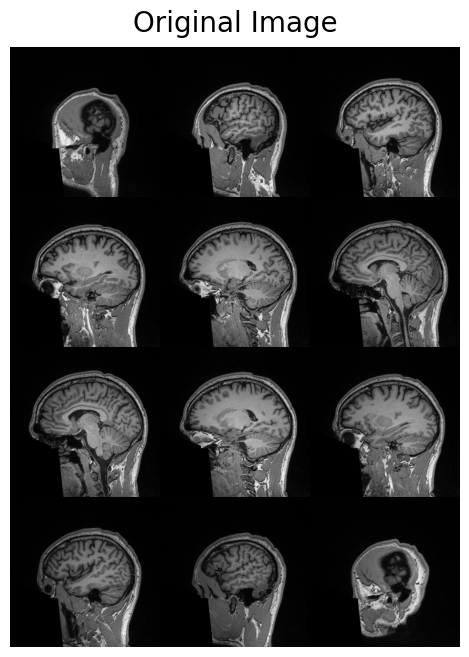

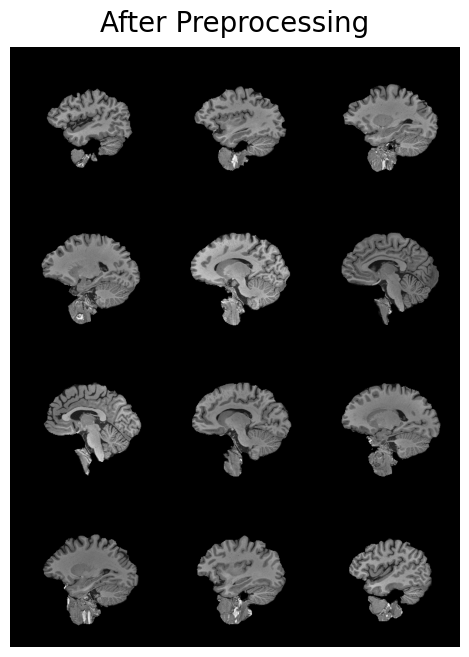

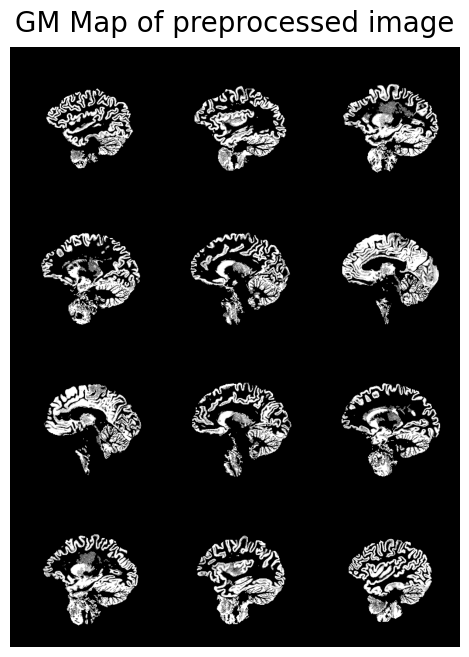

In [4]:
import ants

img_before = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\sub-01_T1w.nii")

img_after = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\sub-01_T1w_reoriented.nii.gz")

img_after2 = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\sub-01_T1w_reoriented_restore.nii.gz")

img_after3 = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\sub-01_T1w_reoriented_seg.nii.gz")

img_after4 = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\brain.nii.gz")

img_after5 = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\brain_mni.nii.gz")

img_after6 = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\brain_intensity_normalized_mni.nii.gz")

img_after7 = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\sub-01_T1w_reoriented_pve_1.nii.gz")

img_after8 = ants.image_read(r"C:\Users\sucha\OneDrive\Documents\schizobrain-Scan\MRI_data\open_neuro\open_neuro_4_99\sub-01_T1w\brain_intensity_normalized_mni_pve_1.nii.gz")

ants.plot(img_before, title="Original Image")
# ants.plot(img_after, title="After reorientation")
# ants.plot(img_after2, title="After Bias field correction")
# ants.plot(img_after3, title="After Tissue classification")
# ants.plot(img_after4, title="After Skull stripping")
# ants.plot(img_after5, title="After Registration to MNI space")
# ants.plot(img_after6, title="After Intensity Normalized MR")
ants.plot(img_after6, title="After Preprocessing")
# ants.plot(img_after7, title="GM Map")
ants.plot(img_after8, title="GM Map of preprocessed image")

In [ ]:
import os
import subprocess
import ants

def preprocess_mri(input_path, output_dir):

    """
    Performs full preprocessing pipeline:
    1. Reorientation
    2. Bias field correction
    3. Skull stripping
    4. Registration to MNI
    5. Intensity normalization
    6. Gray matter map generation

    Returns:
        image_after6 -> fully preprocessed MRI
        image_after8 -> gray matter map
    """

    # ---------- Step 0: Paths ----------
    reoriented = os.path.join(output_dir, "reoriented.nii.gz")
    restore = os.path.join(output_dir, "reoriented_restore.nii.gz")
    brain = os.path.join(output_dir, "brain.nii.gz")
    brain_mni = os.path.join(output_dir, "brain_mni.nii.gz")
    normalized = os.path.join(output_dir, "brain_intensity_normalized_mni.nii.gz")
    gm_map = os.path.join(output_dir, "brain_intensity_normalized_mni_pve_1.nii.gz")
    mat = os.path.join(output_dir, "brain_to_mni.mat")

    # ---------- Step 1: Reorientation ----------
    subprocess.run([
        "fslreorient2std",
        input_path,
        reoriented
    ], check=True)

    # ---------- Step 2: Bias field correction ----------
    subprocess.run([
        "fast",
        "-B",
        reoriented
    ], check=True)

    # FAST automatically creates restore file
    restore = reoriented.replace(".nii.gz", "_restore.nii.gz")

    # ---------- Step 3: Skull stripping ----------
    subprocess.run([
        "bet",
        restore,
        brain
    ], check=True)

    # ---------- Step 4: Registration to MNI ----------
    subprocess.run([
        "flirt",
        "-in", brain,
        "-ref", os.environ["FSLDIR"] + "/data/standard/MNI152_T1_1mm_brain.nii.gz",
        "-out", brain_mni,
        "-omat", mat
    ], check=True)

    # ---------- Step 5: Intensity normalization ----------
    mean_intensity = subprocess.check_output(
        ["fslstats", brain_mni, "-M"]
    ).decode().strip()

    subprocess.run([
        "fslmaths",
        brain_mni,
        "-div", mean_intensity,
        normalized
    ], check=True)

    # ---------- Step 6: GM Map ----------
    subprocess.run([
        "fast",
        normalized
    ], check=True)

    # ---------- Load images with ANTs ----------
    image_after6 = ants.image_read(normalized)
    image_after8 = ants.image_read(gm_map)

    return image_after6, image_after8


In [35]:
print("Before shape:", img_after4.shape)
print("After shape:", img_after5.shape)

print("Before spacing:", img_after4.spacing)
print("After spacing:", img_after5.spacing)

Before shape: (176, 256, 256)
After shape: (176, 256, 256)
Before spacing: (1.0, 1.0, 1.0)
After spacing: (1.0, 1.0, 1.0)
